In [ ]:
# 参数设置
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
from celue.data import x_coords, y_coords, demands
from celue.target import objective_function
from celue.MSGWO import MSGWO
from celue.EGWO import EGWO
from celue.PGWO import PGWO
# # n = 500
m = 12   # 充电站数量
num_wolves=30
max_iter=100

In [2]:

import time
B = [[None for _ in range(0)] for _ in range(3)]
C = [[None for _ in range(0)] for _ in range(3)]
F = np.full(3, np.inf)
Capacity = [[None for _ in range(0)] for _ in range(3)]
Times = np.zeros(3)  # 记录每个算法的运行时间
# 实例化和优化
algorithms = [
    PGWO(objective_function, x_coords, y_coords, demands,m,num_wolves, max_iter),
    EGWO(objective_function, x_coords, y_coords, demands,m,num_wolves, max_iter),
    MSGWO(objective_function, x_coords, y_coords, demands,m,num_wolves, max_iter)
]

for index, algorithm in enumerate(algorithms):
    start_time = time.time()
    best_position, best_score, convergence_curve,capacity = algorithm.optimize()
    end_time = time.time()
    runtime = end_time - start_time
    F[index] = best_score
    B[index] = best_position
    Capacity[index] = capacity
    C[index] = convergence_curve
    Times[index] = runtime

print("Best scores:", F)
# print("Best positions:", B)
print("Capacity:", Capacity)
# print("Convergence curves:", C) 
print("Runtimes:", Times)    

*************GWO****************
最优位置： [0.09 0.48 0.28 0.05 0.74 0.94 0.1  0.84 0.42 0.38 0.38 0.88]
最优容量： [160.43315304 147.21053241  34.15156124 107.91368614 136.42214475
  47.47227408]
最优目标函数值： 633.2054085004239
*************GWO****************
最优位置： [0.09 0.48 0.24 0.22 0.74 0.94 0.64 0.36 0.22 0.15 0.1  0.84]
最优容量： [137.08270923 123.12212539  43.42800448  60.29841925 123.56257632
 146.10951699]
最优目标函数值： 609.3608658670211
*************MSGWO****************
最优位置： [0.1  0.84 0.24 0.22 0.38 0.88 0.09 0.48 0.64 0.36 0.86 0.74]
最优容量： [107.91368614 246.68470171  49.15221044 137.08270923  60.29841925
  32.47162488]
最优目标函数值： 582.157561090977
Best scores: [633.2054085  609.36086587 582.15756109]
Capacity: [array([160.43315304, 147.21053241,  34.15156124, 107.91368614,
       136.42214475,  47.47227408]), array([137.08270923, 123.12212539,  43.42800448,  60.29841925,
       123.56257632, 146.10951699]), array([107.91368614, 246.68470171,  49.15221044, 137.08270923,
        60.29841925,  32.4

In [3]:
for i in range(len(F)):   
    print(F[i])

633.2054085004239
609.3608658670211
582.157561090977


In [4]:
for i in range(len(Times)):   
    print(Times[i])

189.27950716018677
187.797753572464
393.71372151374817


In [5]:
from CSLP1.zhibiao import zhibiao
AD = []
BD = []
CD = []
for i in range(len(B)):
    TD,AVGD,MAXD = zhibiao(B[i],x_coords,y_coords)
    AD.append(TD)
    BD.append(AVGD)
    CD.append(MAXD)

In [6]:
for i in range(len(AD)):
    print(AD[i])
print("*********************")
for i in range(len(BD)):
    print(BD[i])
print("*********************")
for i in range(len(CD)):
    print(CD[i])

633.2054085004239
609.3608658670211
582.157561090977
*********************
0.1359685223320644
0.1308483714552332
0.12500699185977604
*********************
0.529936995062546
0.36160369518597013
0.36160369518597013


In [7]:
# for i in range(len(C)):
#     print(C)

In [8]:
from celue.NearP import near1

A = []
for i in range(len(B)):
    a = near1(B[i],m)
    print(a)
    A.append(a)

[28, 29, 17, 36, 3, 1]
[28, 4, 17, 11, 29, 36]
[36, 4, 1, 28, 11, 8]


In [9]:

# stations_positions = best_position.reshape((m, 3))[:, :2]
# stations_capacities = best_position.reshape((m, 3))[:, 2]
# 绘制收敛曲线
'''plt.rcParams['font.family'] = 'Times New Roman'
def plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors):
    plt.figure(figsize=(26, 16))

    for curve, label, color in zip(curves, labels, colors):
        plt.plot(curve, label=label, color=color, linewidth=7)  # 增加线条粗细
    plt.xlabel('Iteration', fontsize=64)
    plt.ylabel('Total Distance(km)', fontsize=64)
    plt.title('CPS04', fontsize=64)
    plt.legend(fontsize=48)
    # plt.grid(True)
    plt.xticks(fontsize=64)
    plt.yticks(fontsize=64)
    plt.savefig('cps04.png', dpi=100)
    plt.show()

    # 使用示例数据运行函数
curves = C
labels = ['GWO', 'MSGWO1', 'MSGWO2','MSGWO']
colors = ['green','orange','blue','red']
plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors)'''

"plt.rcParams['font.family'] = 'Times New Roman'\ndef plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors):\n    plt.figure(figsize=(26, 16))\n\n    for curve, label, color in zip(curves, labels, colors):\n        plt.plot(curve, label=label, color=color, linewidth=7)  # 增加线条粗细\n    plt.xlabel('Iteration', fontsize=64)\n    plt.ylabel('Total Distance(km)', fontsize=64)\n    plt.title('CPS04', fontsize=64)\n    plt.legend(fontsize=48)\n    # plt.grid(True)\n    plt.xticks(fontsize=64)\n    plt.yticks(fontsize=64)\n    plt.savefig('cps04.png', dpi=100)\n    plt.show()\n\n    # 使用示例数据运行函数\ncurves = C\nlabels = ['GWO', 'MSGWO1', 'MSGWO2','MSGWO']\ncolors = ['green','orange','blue','red']\nplot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors)"

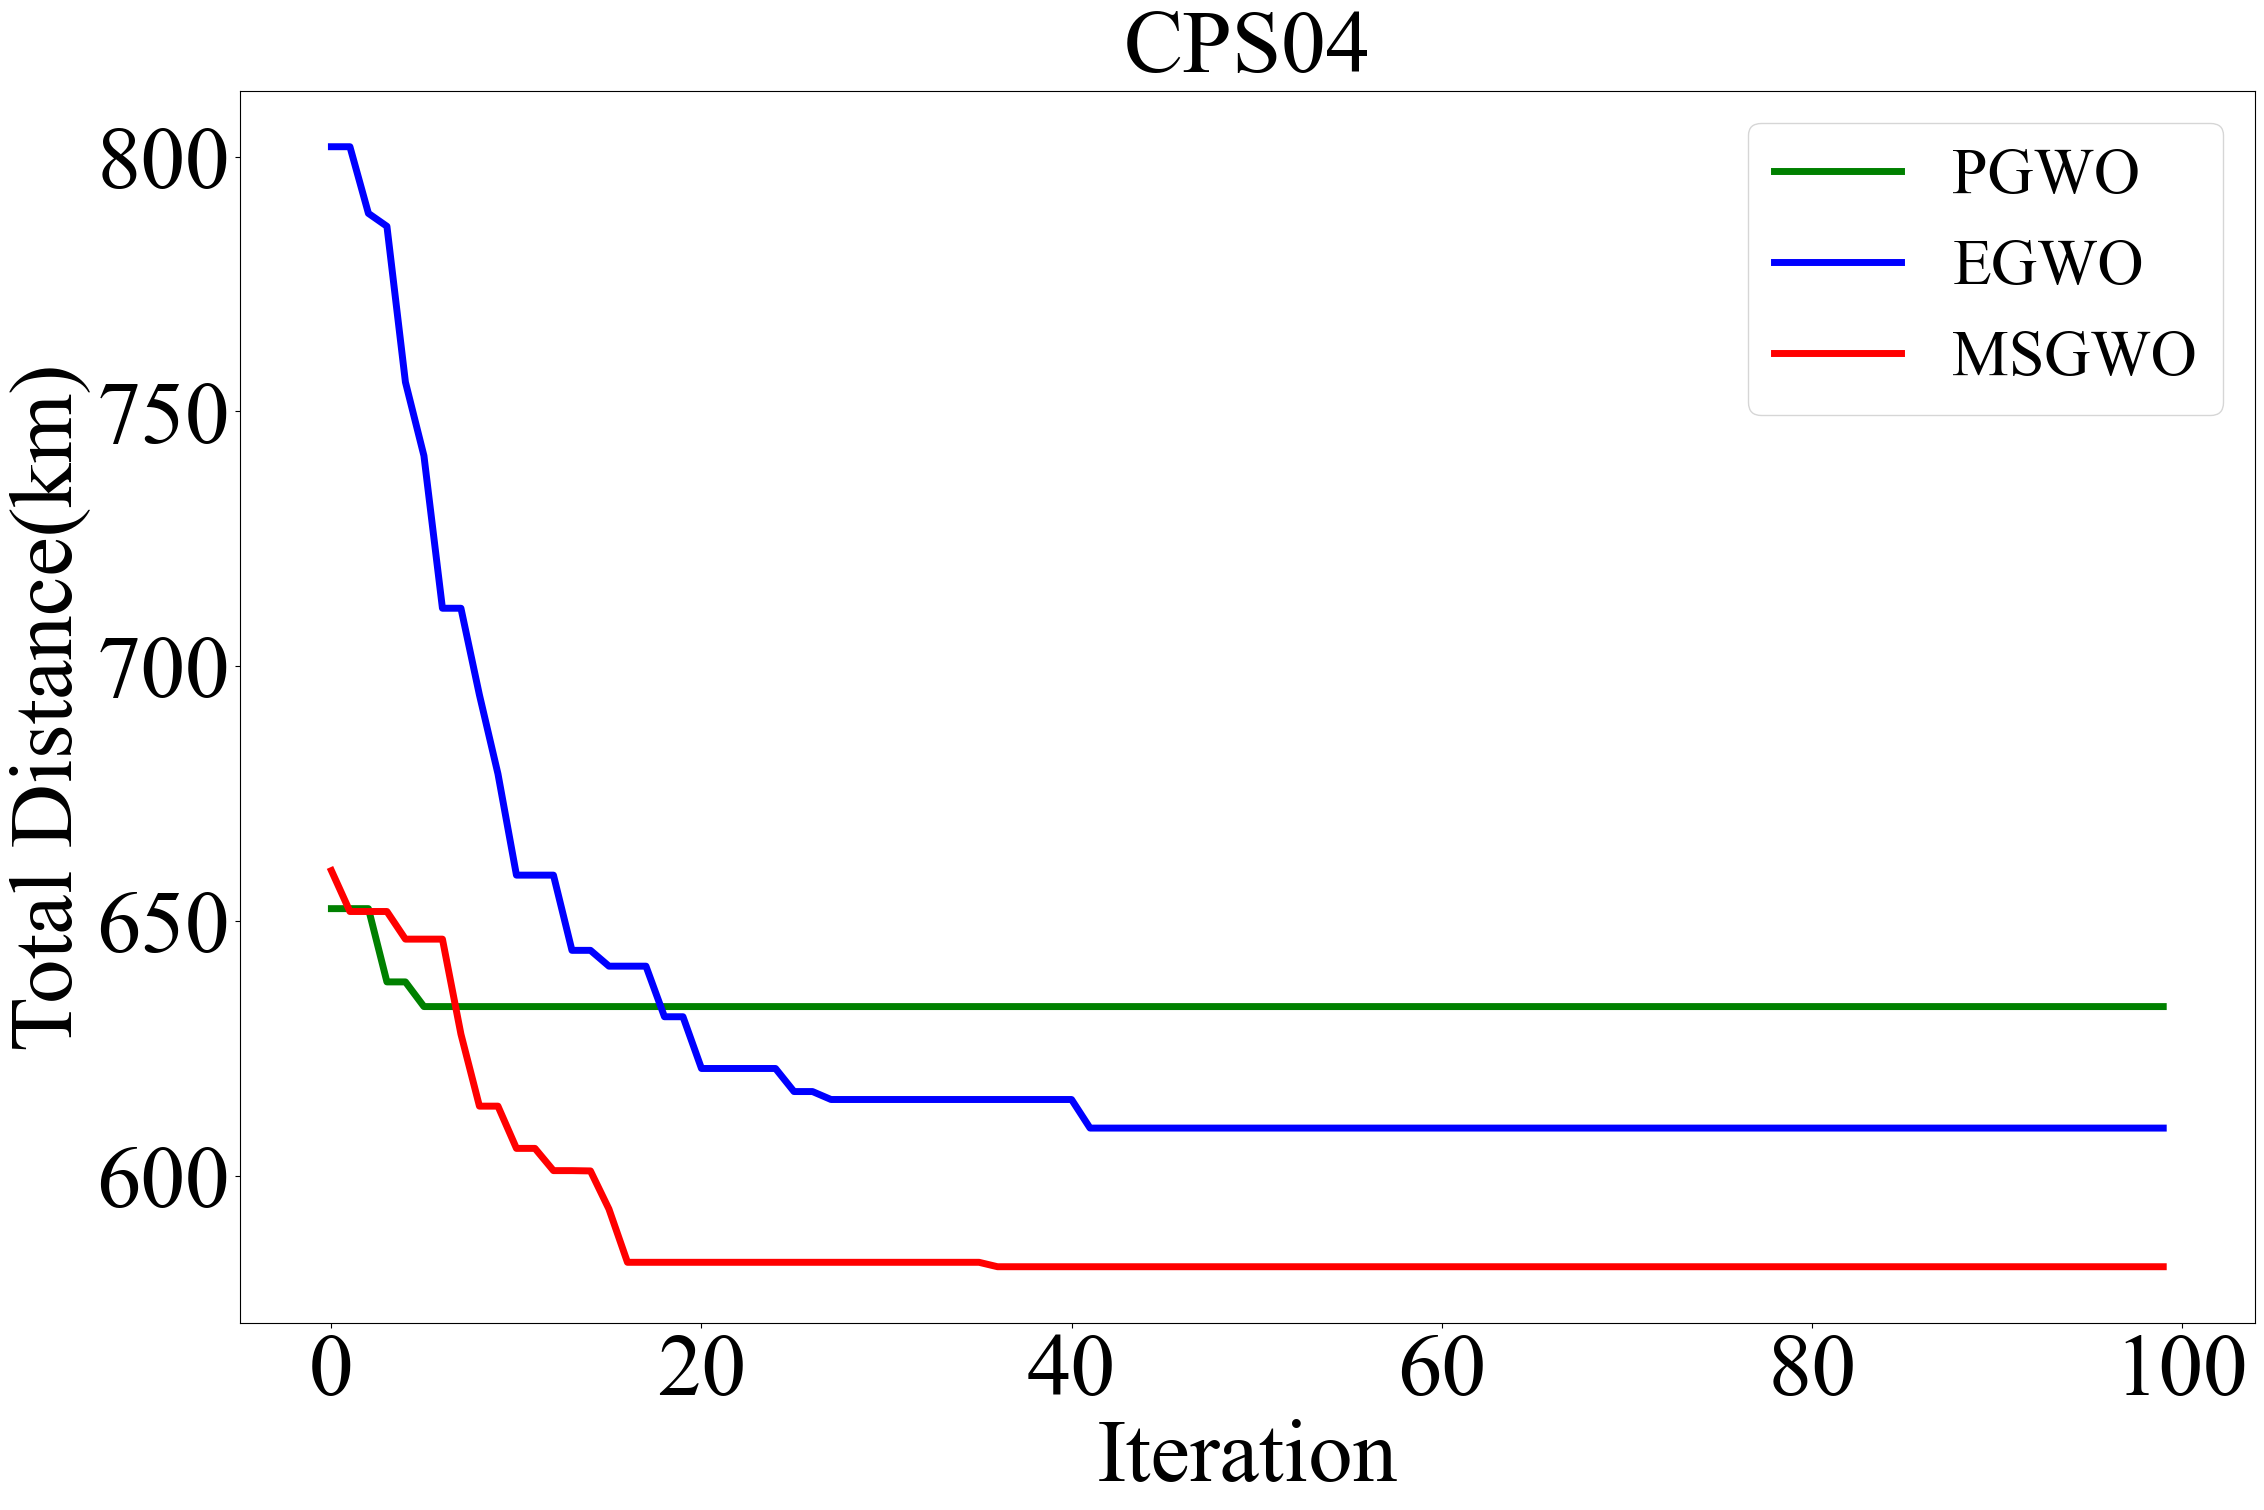

In [10]:
from matplotlib import pyplot as plt
# 绘制收敛曲线
plt.rcParams['font.family'] = 'Times New Roman'
def plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors, final_curve, final_label, final_color):
    plt.figure(figsize=(26, 16))

    for curve, label, color in zip(curves, labels, colors):
        plt.plot(curve, label=label, color=color, linewidth=5)  # 增加线条粗细
    # Plot the final curve with a different style
    plt.plot(final_curve, label=final_label, color=final_color, linewidth=5)  # 增加最终线条的粗细
    plt.xlabel('Iteration', fontsize=64)
    plt.ylabel('Total Distance(km)', fontsize=64)
    plt.title('CPS04', fontsize=64)
    plt.legend(fontsize=46)
    # plt.grid(True)
    plt.xticks(fontsize=64)
    plt.yticks(fontsize=64)
    # Save the figure with no white border
    plt.savefig('cps04.png', dpi=96, bbox_inches='tight')
    plt.show()

    # 使用示例数据运行函数
C = C[:3]
curves = C[:-1]
labels = ['PGWO', 'EGWO']
colors = ['green','blue']
final_curve = C[-1]
final_label = 'MSGWO'
final_color = 'red'
plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors, final_curve, final_label, final_color)

In [11]:
import os
import pandas as pd
from openpyxl import load_workbook

def append_to_excel(filename, data_list):
    # 将列表转换为DataFrame
    df = pd.DataFrame([data_list])

    # 检查文件是否存在
    if not os.path.isfile(filename):
        # 如果文件不存在，创建新文件并写入数据，包含表头
        df.to_excel(filename, index=False, header=True)
    else:
        # 文件存在，尝试追加数据
        try:
            # 加载现有工作簿，并指定只读取数据，不读取样式等
            book = load_workbook(filename, data_only=True)

            # 确保Sheet1存在
            if 'Sheet1' not in book.sheetnames:
                book.create_sheet('Sheet1')

            # 找到Sheet1中的最后一行
            startrow = book['Sheet1'].max_row

            # 使用pandas的ExcelWriter以追加模式写入数据
            with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
                # 将数据追加到Sheet1
                df.to_excel(writer, sheet_name='Sheet1', startrow=startrow, index=False, header=False)

        except Exception as e:
            print(f"在追加数据时发生错误: {e}")
filename = "C1.xlsx"
# 追加数据到Excel文件
for i in range(len(C)):
    append_to_excel(filename, C[i])

print(f"数据已成功写入 {filename}")

数据已成功写入 C1.xlsx


In [12]:
 # from CSLP1.data import x
# 
# print(len(x))